In [1]:
import numpy as np
import matplotlib.pyplot as plt
import h5py as h5
import sys

from scipy.optimize import curve_fit
import scipy
from tqdm import tqdm

from colossus.cosmology import cosmology
cosmo = cosmology.setCosmology('planck13')
a = 0.83760
redshift=1/a-1
H = cosmo.Hz(redshift)
h = cosmo.h
#print(cosmo.h, cosmo.Hz(redshift), cosmo.H0*cosmo.Ez(redshift))

sys.path.append('/home/cosweeney/code/Fits/')

sys.path.append('/home/cosweeney/code/Fits/Jocond')

from JoCond.jocond.losvd import *
from JoCond.jocond.cat import *
from JoCond.jocond.mass_calibration import *

import matplotlib
matplotlib.rcParams.update({'text.usetex': True, 
                            'font.family': 'Computer Modern Roman'})

# automatic reload of modules 
%load_ext autoreload
%autoreload 2

In [4]:
# bin MDPL2 data 

# Mass bin centers
Rvirs, Mvirs, mbins = compute_bin_virial_R_M('/spiff/cosweeney/Tables/halo_pair_cat_final2_HD.hdf5')

# radial bins
r_edges = np.linspace(5, 15, (15-5)+1)
r_cens = (r_edges[1:]+r_edges[:-1])/2.0

vel_path = '/spiff/cosweeney/simulations/MDPL2/data/pairwise_velocity_selections/r_R_rlos_vpeclos_vphyslos_data_mass_100_cyl_6K_indmass.hdf5'

vpeclos_ls  = []
vphyslos_ls = []
rlos_ls = []
R_ls = []
M_ls = []

with h5.File(vel_path, 'r') as hdf:
    for k, M in enumerate(Mvirs):
        rel_R = hdf[f'R/{k}'][()]
        rel_rlos = hdf[f'rlos/{k}'][()]
        vpec = hdf[f'vpeclos/{k}'][()]
        vphys = hdf[f'vphyslos/{k}'][()]
        Mvir = hdf[f'Mvir/{k}'][()]
        
        # Use digitize to bin all at once
        bin_indices = np.digitize(rel_R, r_edges) - 1
        
        for i in range(len(r_cens)):
            mask = bin_indices == i
            vpeclos_ls.append(vpec[mask])
            #vphyslos_ls.append(vpec[mask] + a*H*rel_rlos[mask]/h)
            vphyslos_ls.append(vphys[mask])
            rlos_ls.append(rel_rlos[mask])
            R_ls.append(rel_R[mask])
            M_ls.append(Mvir[mask])

massbin edges, in h^-1 sol mass: [8.00020227e+13 1.22732852e+14 1.88287152e+14 2.88855436e+14
 4.43139440e+14 6.79829904e+14 1.60000000e+15]


In [5]:
# compute histograms
bin_num = 50 

LOS_hists_MDPL2 = np.zeros((bin_num, len(Mvirs), len(r_cens)))


vedges = np.linspace(-2500, 2500, bin_num+1)
vcens = 0.5*(vedges[1:]+vedges[:-1])


for k in range(len(Mvirs)):
    for i in range(len(r_cens)):
        index = i + len(r_cens)*k

        hist, v_edges = np.histogram(vphyslos_ls[index], bins=bin_num, range=[-2500, 2500], density=False)

        v_cens = (v_edges[:-1] + v_edges[1:]) / 2 

        LOS_hists_MDPL2[:, k, i] = hist  


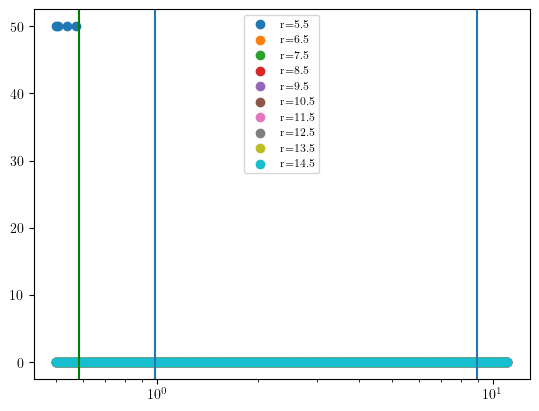

In [12]:
path = '/spiff/cosweeney/simulations/MDPL2/data/Pvlos_mass_grids/Pvlos_M_grid_R_5_15_gal.npy'

P_vlos_grid = np.load(path)


Mvals = np.logspace(np.log10(0.5), np.log10(11), 200)  #np.logspace(np.log10(0.1), np.log10(20), 100) # grid of Mvals

nangrid = np.zeros((len(r_cens), len(Mvals)))

for i in range(len(r_cens)):
    for j in range(len(Mvals)):
        mask = np.isnan(P_vlos_grid[:, i, j])

        if np.sum(mask) > 0:
            nangrid[i, j] = np.sum(mask)

for i in range(len(r_cens[:10])):
    plt.scatter(Mvals, nangrid[i, :], label=f'r={r_cens[i]}')
plt.xscale('log')
plt.axvline(Mvirs[0]/1e14)
plt.axvline(Mvirs[-1]/1e14)
plt.axvline(Mvals[10], c='g')
#plt.axvline(Mvals[95], c='g')

plt.legend(fontsize=8)

In [11]:
P_vlos_grid.shape

(50, 10, 200)

In [8]:
mbins

array([8.00020227e+13, 1.22732852e+14, 1.88287152e+14, 2.88855436e+14,
       4.43139440e+14, 6.79829904e+14, 1.60000000e+15])

In [13]:
# fit using mass_calibration class
Mvals = np.logspace(np.log10(0.5), np.log10(11), 200) 

M_p = 1e14  # h^-1 M_sun

mc = MassCalibrator(r_cens, 
                    Mvirs, 
                    mbins, 
                    vedges, 
                    LOS_hists_MDPL2, 
                    grid_path=path, 
                    Mvals=Mvals)

In [14]:
mc.calibrate_full(print_mess=False)

Fitting individual R bins...


/home/cosweeney/code/Fits/JoCond/jocond/mass_calibration.py:73: RuntimeWarning: invalid value encountered in log
  return - 0.5 * np.sum(chisq + np.log(sigmasq))
/home/cosweeney/code/Fits/JoCond/jocond/mass_calibration.py:73: RuntimeWarning: invalid value encountered in log
  return - 0.5 * np.sum(chisq + np.log(sigmasq))
/home/cosweeney/code/Fits/JoCond/jocond/mass_calibration.py:73: RuntimeWarning: invalid value encountered in log
  return - 0.5 * np.sum(chisq + np.log(sigmasq))
/home/cosweeney/code/Fits/JoCond/jocond/mass_calibration.py:73: RuntimeWarning: invalid value encountered in log
  return - 0.5 * np.sum(chisq + np.log(sigmasq))
/home/cosweeney/code/Fits/JoCond/jocond/mass_calibration.py:73: RuntimeWarning: invalid value encountered in log
  return - 0.5 * np.sum(chisq + np.log(sigmasq))
/home/cosweeney/code/Fits/JoCond/jocond/mass_calibration.py:73: RuntimeWarning: invalid value encountered in log
  return - 0.5 * np.sum(chisq + np.log(sigmasq))


Fitting bins simultaneously...


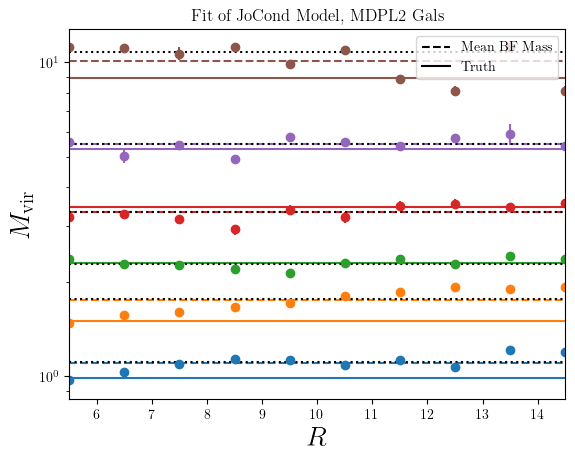

In [17]:
mc.plot_indiv_fits()

plt.title(r"Fit of JoCond Model, MDPL2 Gals")

for k in range(len(mc.mvirs)):
    plt.axhline(np.median(mc.par_mass_ind[k, :, 0]), c=f'k', ls=':') 

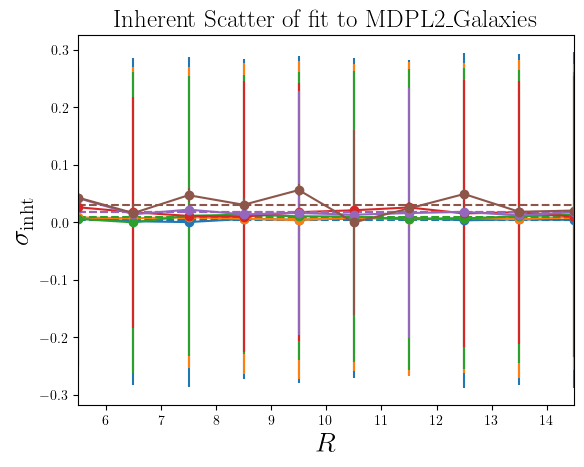

In [18]:
mc.plot_indiv_scatter()

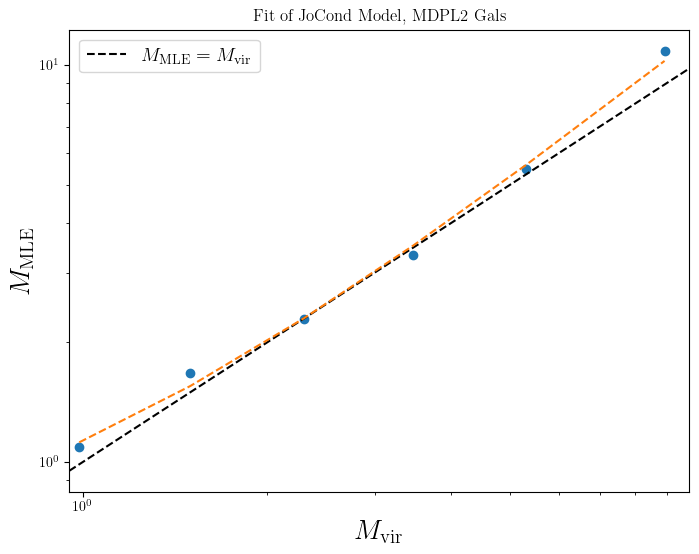

In [28]:
mc.plot_simult_fits()

plt.title(r"Fit of JoCond Model, MDPL2 Gals")
p, c = curve_fit(lambda x, a, b, c: a*x**b + c, mc.mvirs, mc.par_mass_sim[:-1], sigma=mc.err_mass_sim[:-1] )

plt.plot(mc.mvirs, p[0]*mc.mvirs**p[1] + p[2], c='C1', ls='--')
# plt.fill_between(mc.mvirs, (1-0.05)*mc.mvirs, (1+0.05)*mc.mvirs, alpha=0.3, color='k')
# plt.fill_between(mc.mvirs, (1-0.1)*mc.mvirs, (1+0.1)*mc.mvirs, alpha=0.1, color='k')

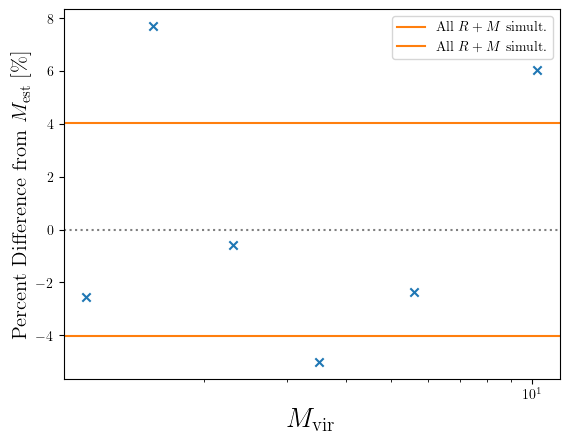

In [29]:
mest = p[0]*mc.mvirs**p[1] + p[2] 

plt.scatter(mest, ((mc.par_mass_sim[:-1]-mest)/mest)*100, marker='x')
plt.axhline(np.mean(np.abs((mc.par_mass_sim[:-1]-mest)/mest))*100, label=r'All $R+M$ simult.', c='C1') 
plt.axhline(-np.mean(np.abs((mc.par_mass_sim[:-1]-mest)/mest))*100, label=r'All $R+M$ simult.', c='C1') 


#plt.axhline(-np.mean(np.abs((mc.par_mass_sim[:-1]-mest)/mest))*100)
plt.axhline(0.0, c='k', ls=':', alpha=0.5)
plt.xlabel(r"$M_{\rm vir}$", fontsize=20) 
plt.ylabel(r"Percent Difference from $M_{\rm est}$ $[\%]$", fontsize=15) 
plt.xscale('log')
plt.legend()

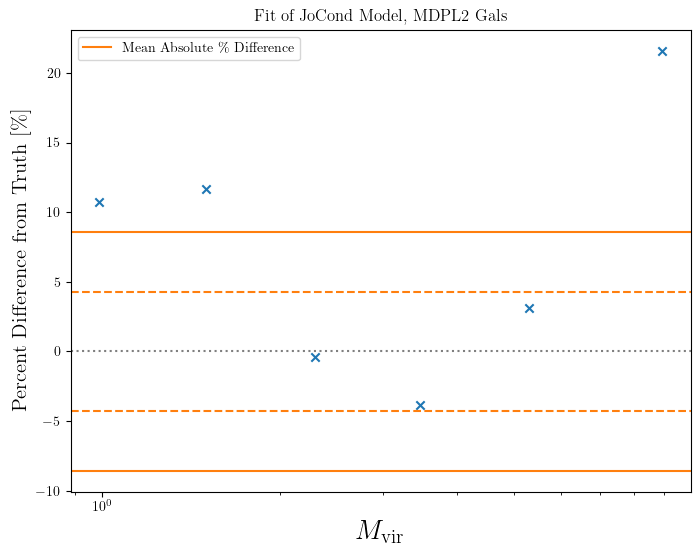

In [30]:
mc.plot_per_diff()
plt.title(r"Fit of JoCond Model, MDPL2 Gals")
plt.axhline(np.mean((mc.par_mass_sim[:-2] - mc.mvirs[:-1] )/mc.mvirs[:-1])*100, c='C1', ls='--', label='excluding highest mass')
plt.axhline(-np.mean((mc.par_mass_sim[:-2] - mc.mvirs[:-1] )/mc.mvirs[:-1])*100, c='C1', ls='--')


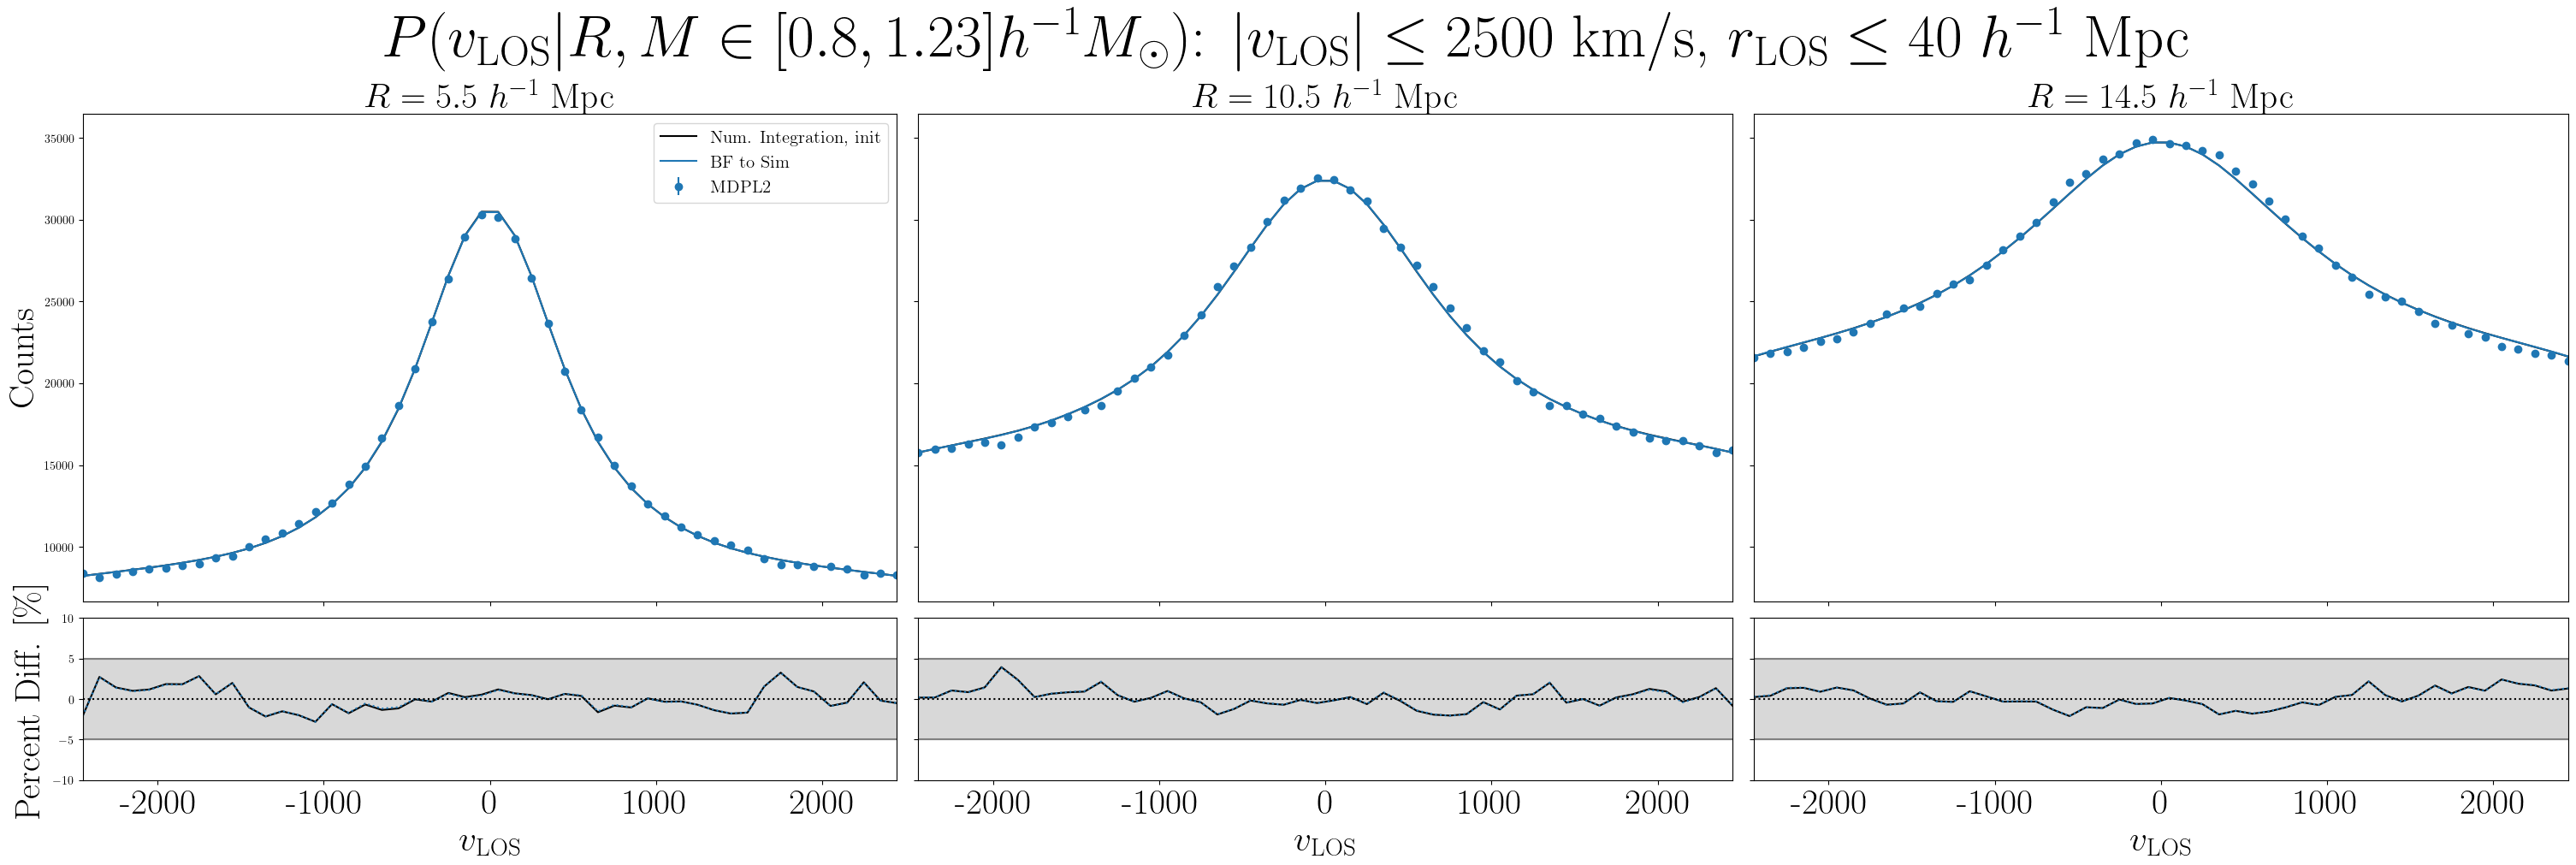

In [13]:
# validate

mvirs = Mvirs/1e14
bin_num = 50 #120

r_select_inds = [0, 5, 9]
r_select = np.array([r_cens[i] for i in r_select_inds]) 

#for j in range(1):
for k in range(len(mvirs)-5):
    #k = 5
    fig, ax = plt.subplots(2, len(r_select), figsize=(30, 10), sharex=True, sharey='row', layout='constrained', gridspec_kw={'height_ratios': [3, 1]}) 
    for i, R in enumerate(r_select):

        index = r_select_inds[i] + k*len(r_cens)
        hist, bins_ex = np.histogram(vphyslos_ls[index], bins=bin_num, range=[-2500, 2500], density=False)
        
        vcens_ex = 0.5*(bins_ex[1:]+bins_ex[:-1])

        dist =  P_vphys_R(vcens, r_select[i], Mvirs[k]) 
        #dist_out = mc.P_vphys_R_int(mc.par_mass_ind[k, r_select_inds[i], 0])[:, r_select_inds[i]]
        dist_out = mc.P_vphys_R_int(Mvirs[k]/1e14)[:, r_select_inds[i]]


        N_avg = np.sum(hist)*dist*np.diff(vcens_ex)[0]
        N_avg3 = np.sum(hist)*dist_out*np.diff(vcens_ex)[0]

        ax[0, i].errorbar(vcens_ex, hist, np.sqrt(hist), fmt='o', c=f'C0', label='MDPL2') #

        ax[0, i].plot(vcens_ex, N_avg, c='k', label='Num. Integration, init')# 
        ax[0, i].plot(vcens_ex, N_avg3, c='C0', label='BF to Sim')# 

        ax[0, i].set_title(r"$R={} \ h^{{-1}}$ Mpc".format(R), fontsize=30)
        ax[0, i].margins(x=0)

        ax[1, i].plot(vcens_ex, (N_avg - hist)/hist * 100, c='k')
        ax[1, i].plot(vcens_ex, (N_avg3 - hist)/hist * 100, ls=':', c='C0')

        ax[1, i].axhline(0.0, c='k', ls=':')
        ax[1, i].axhline(5, c='gray', ls='-')
        ax[1, i].fill_between(vcens_ex, 5, -5, color='gray', alpha=0.3)
        ax[1, i].axhline(-5, c='gray', ls='-')
        ax[1, i].set_ylim((-10, 10))
        ax[1, i].margins(x=0)
        ax[1, i].set_xlabel(r'$v_{\rm LOS}$', fontsize=30)
        ax[1, i].set_xticks([-2000, -1000, 0, 1000, 2000])
        ax[1, i].set_xticklabels(['-2000', '-1000', '0', '1000', '2000'], fontsize=30)
    ax[0, 0].legend(loc='upper right', fontsize=15)
    ax[0, 0].set_ylabel(r'Counts', fontsize=30)
    ax[1, 0].set_ylabel(r'Percent Diff. $[\%]$', fontsize=30)
    fig.suptitle(r"$P(v_{{\rm LOS}}|R, M\in[{}, {}] h^{{-1}}M_\odot)$: $|v_{{\rm LOS}}| \leq {}$ km/s, $r_{{\rm LOS}} \leq 40 \ h^{{-1}}$ Mpc".format(round(mbins[k]/1e14, 2), round(mbins[k+1]/1e14, 2), 2500), fontsize=50)  
    

/tmp/ipykernel_2535380/1695013315.py:43: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[0].legend(loc='upper right', fontsize=10)


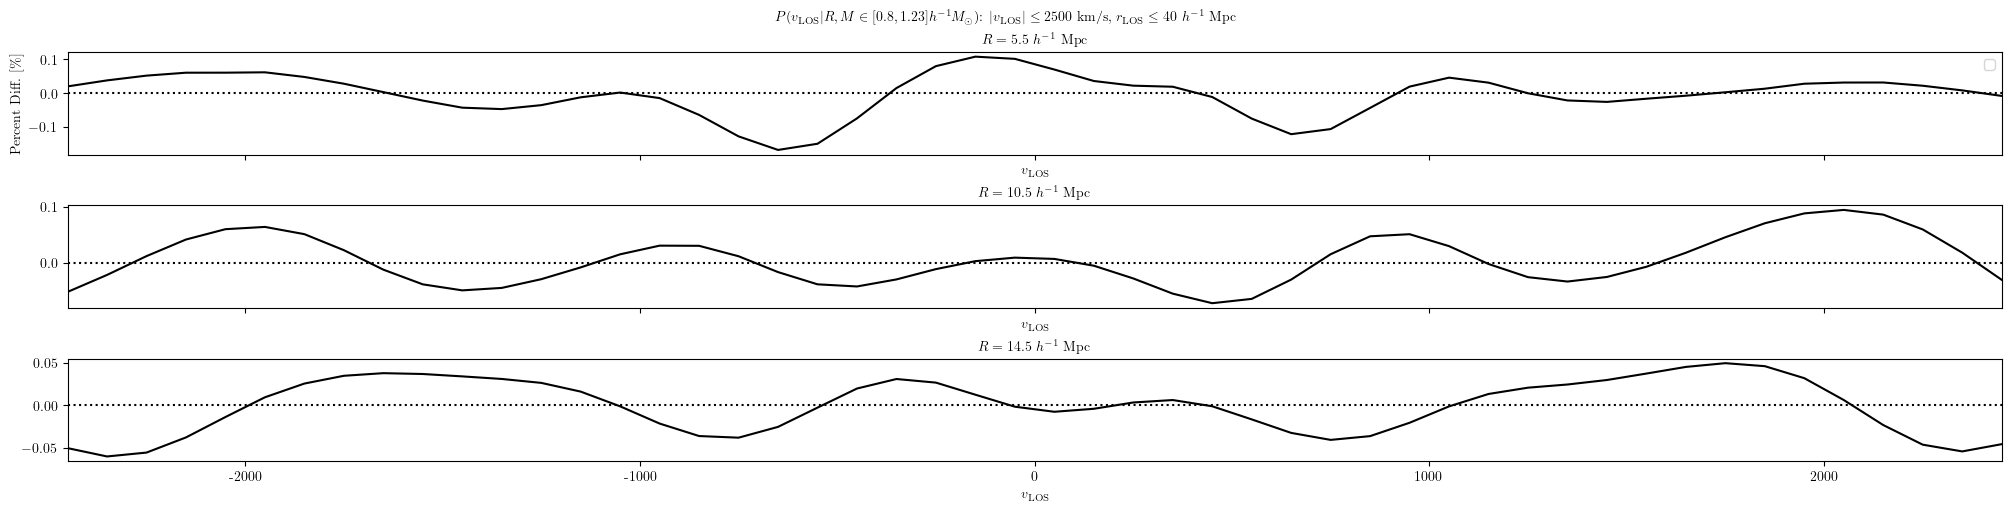

In [50]:
# validate

mvirs = Mvirs/1e14
bin_num = 50 #120

r_select_inds = [0, 5, 9]
r_select = np.array([r_cens[i] for i in r_select_inds]) 

#for j in range(1):
for k in range(len(mvirs)-5):
    #k = 5
    fig, ax = plt.subplots(len(r_select), figsize=(20, 5), sharex=True, sharey='row', layout='constrained') 
    for i, R in enumerate(r_select):

        index = r_select_inds[i] + k*len(r_cens)
        hist, bins_ex = np.histogram(vphyslos_ls[index], bins=bin_num, range=[-2500, 2500], density=False)
        
        vcens_ex = 0.5*(bins_ex[1:]+bins_ex[:-1])

        dist =  P_vphys_R(vcens, r_select[i], Mvirs[k]) 
        #dist_out = mc.P_vphys_R_int(mc.par_mass_ind[k, r_select_inds[i], 0])[:, r_select_inds[i]]
        dist_out = mc.P_vphys_R_int(Mvirs[k]/1e14)[:, r_select_inds[i]]


        N_avg = np.sum(hist)*dist*np.diff(vcens_ex)[0]
        N_avg3 = np.sum(hist)*dist_out*np.diff(vcens_ex)[0]

        ax[i].set_title(r"$R={} \ h^{{-1}}$ Mpc".format(R), fontsize=10)
        ax[i].margins(x=0)

        ax[i].plot(vcens_ex, (N_avg - N_avg3)/N_avg3 * 100, c='k')
        #ax[i].plot(vcens_ex, (N_avg3 - hist)/hist * 100, ls=':', c='C0')

        ax[i].axhline(0.0, c='k', ls=':')
        #ax[i].axhline(5, c='gray', ls='-')
        #ax[i].fill_between(vcens_ex, 5, -5, color='gray', alpha=0.3)
        #ax[i].axhline(-5, c='gray', ls='-')
        #ax[i].set_ylim((-10, 10))
        ax[i].margins(x=0)
        ax[i].set_xlabel(r'$v_{\rm LOS}$', fontsize=10)
        ax[i].set_xticks([-2000, -1000, 0, 1000, 2000])
        ax[i].set_xticklabels(['-2000', '-1000', '0', '1000', '2000'], fontsize=10)
    ax[0].legend(loc='upper right', fontsize=10)
    #ax[0].set_ylabel(r'Counts', fontsize=10)
    ax[0].set_ylabel(r'Percent Diff. $[\%]$', fontsize=10)
    fig.suptitle(r"$P(v_{{\rm LOS}}|R, M\in[{}, {}] h^{{-1}}M_\odot)$: $|v_{{\rm LOS}}| \leq {}$ km/s, $r_{{\rm LOS}} \leq 40 \ h^{{-1}}$ Mpc".format(round(mbins[k]/1e14, 2), round(mbins[k+1]/1e14, 2), 2500), fontsize=10)  
    

In [42]:
%%timeit

dist =  P_vphys_R(vcens, r_select[i], Mvirs[k]) 

5.91 s ± 146 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [43]:
%%timeit
dist_out = mc.P_vphys_R_int(Mvirs[k]/1e14)[:, r_select_inds[i]]

1.96 ms ± 43.6 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [44]:
5.91/(0.00196)

3015.3061224489797

In [45]:
# no interpolation

def RG_llh_ind_no_int(pars, data, r_ind):
    M, s = pars 

    dv = (vedges[-1]-vedges[0])/(len(vedges)-1)

    M_p = 1e14

    dist = P_vphys_R(vcens, r_cens[r_ind], M) #P_vphys_R_int(M)[:, r_ind]
    #dist = dist / np.sum(dist*dv)

    N_avg = np.sum(data) * dist * dv

    sigmasq = N_avg + s**2 * N_avg**2

    chisq = ((data) - N_avg)**2 / sigmasq  

    return - 0.5 * np.sum(chisq + np.log(sigmasq))

In [47]:
mvirs = Mvirs/1e14

par_mass_ind = np.zeros((len(mvirs), len(r_cens), 2))
err_mass_ind = np.zeros((len(mvirs), len(r_cens), 2))

for k in range(len(mvirs)):
    p_init = [mvirs[k], 0.01] #[Mvirs[0]/1e14, 0.1]

    for i in range(len(r_cens)):
        soln = scipy.optimize.minimize(lambda p: -RG_llh_ind_no_int(p, LOS_hists_MDPL2[:, k, i], i), p_init, 
                                    bounds = [(0.5, 20.0), (0, 10)], #(0, np.inf), (0, np.inf), (0, np.inf)], 
                                    method='nelder-mead', 
                                    )
        
        print("Initial: ", p_init) 
        print("MLE: ", soln.x) 
        print(soln.message)

        par_mass_ind[k, i] = soln.x 

/home/cosweeney/code/Fits/JoCond/jocond/losvd.py:51: RuntimeWarning: invalid value encountered in divide
  return P_out / np.sum(P_out * np.diff(vlos)[0])
/home/cosweeney/code/Fits/JoCond/jocond/joint.py:33: RuntimeWarning: overflow encountered in scalar power
  return p * x**s


Initial:  [np.float32(0.98642004), 0.01]
MLE:  [0.98642004 0.01      ]
Maximum number of function evaluations has been exceeded.


/home/cosweeney/miniconda3/envs/scienv/lib/python3.12/site-packages/scipy/stats/_continuous_distns.py:361: RuntimeWarning: overflow encountered in square
  return np.exp(-x**2/2.0) / _norm_pdf_C
/home/cosweeney/code/Fits/JoCond/jocond/joint.py:428: RuntimeWarning: invalid value encountered in divide
  return jd / norm
/home/cosweeney/code/Fits/JoCond/jocond/joint.py:33: RuntimeWarning: overflow encountered in scalar multiply
  return p * x**s


KeyboardInterrupt: 

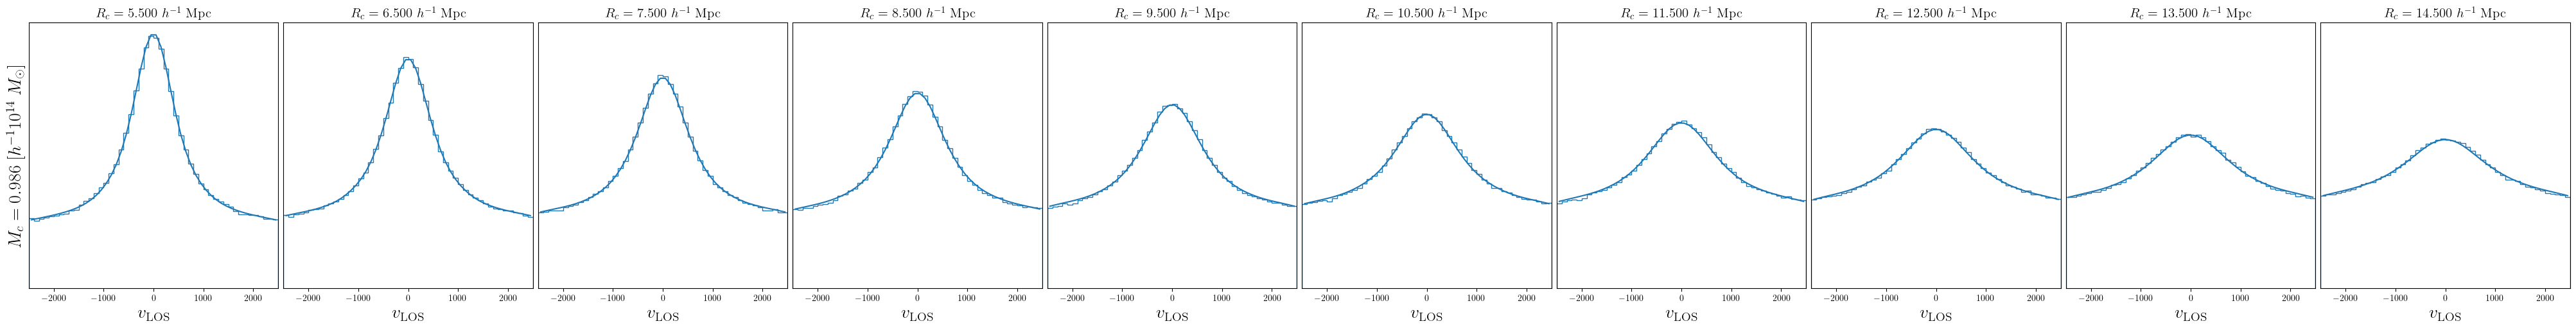

In [10]:

for k in range(len(Mvirs)-5):
    fig, ax = plt.subplots(1, len(r_cens), figsize=(40, 5), layout='constrained', sharex=True, sharey=True)
    for i in range(len(r_cens)):
        index = i + k*len(r_cens)

        hist, bins, _ = ax[i].hist(vphyslos_ls[index], bins=vedges, density=True, histtype='step', color=f'C{k}')

        ax[i].plot(vcens, P_vphys_R(vcens, r_cens[i], Mvirs[k]), c=f'C{k}')
        
        ax[i].set_xlabel(r"$v_{\rm LOS}$", fontsize=20)
        ax[i].set_title(rf"$R_c = {r_cens[i]:.3f} \ h^{{-1}}$ Mpc", fontsize=15)
        ax[i].set_yticks([])
        ax[i].margins(x=0)
    ax[0].set_ylabel(rf"$M_c = {(Mvirs[k]/1e14):.3f} \ [h^{{-1}} 10^{{14}} \ M_\odot]$", fontsize=20)

In [40]:
def P_vphys_R_test(vphys, R, M, pars=jocond.myconfig.joint_MAP, H=74.719, a=0.83760, h=0.6777):
    """Projected distribution of physical LOS velocities, obtained by
    numerical integration over the joint distribution of peculiar velocities.

    Args:
        vphys (_type_): Physical LOS velocity bins centers.
        R (_type_): Projected radial separation bin centers.
        M (_type_): Mass bin centers.
        H (float, optional): Hubble parameter at this z. Defaults to 74.719 km/s/Mpc.
        a (float, optional): Scale factor. Defaults to 0.83760.
        h (float, optional): Reduced Hubble parameter. Defaults to 0.6777.

    Returns:
        np.ndarray: Distribution of velocities in bins of vphys, R, M.
    """
    rho_g = 0.014  # h^3 Mpc^-3 mean galaxy number density in MDPL2

    # rlos integration range
    rlos_max = 40 
    rlos_edges = np.linspace(-rlos_max, rlos_max, int(2*rlos_max + 1))
    rlos_vals = 0.5 * (rlos_edges[1:] + rlos_edges[:-1])

    Pvlos_interp_list = []

    for j in range(len(rlos_vals)):
        peak = a*H*rlos_vals[j]/h

        ve = np.linspace(-2500, 2500, 100+1)
        vc = 0.5 * (ve[1:] + ve[:-1])

        Pvlos = P_vlos_R_rlos(vc, R, rlos_vals[j], M, pars)

        interp_func = interp1d(
            vc+peak, Pvlos, kind="linear", bounds_error=False, fill_value=0.0
        )
        interpolated = interp_func(vphys[:, None])

        Pvlos_interp_list.append(interpolated)

    Pvlos_interp = np.array(Pvlos_interp_list).reshape(len(rlos_vals), len(vphys))
    Pvlos_interp = Pvlos_interp.T

    r3d = np.sqrt(R**2 + rlos_vals**2)
    weight = rho_g * (cf_inf(r3d, M, jocond.myconfig.cf_pars) + 1)

    integrand = Pvlos_interp * weight[None, :]
    P_out = simpson(integrand, x=rlos_vals, axis=1)

    sigma_R = Sigma_inf(R, M, jocond.myconfig.cf_pars, max_rlos=40)
    P_out /= sigma_R

    return P_out #/ np.sum(P_out * np.diff(vphys)[0])


In [35]:
LOS_hists_MDPL2.shape

(50, 6, 10)

In [41]:
test = P_vphys_R(vcens, r_cens[0], Mvirs[0])
test2 = P_vphys_R_test(vcens, r_cens[0], Mvirs[0])

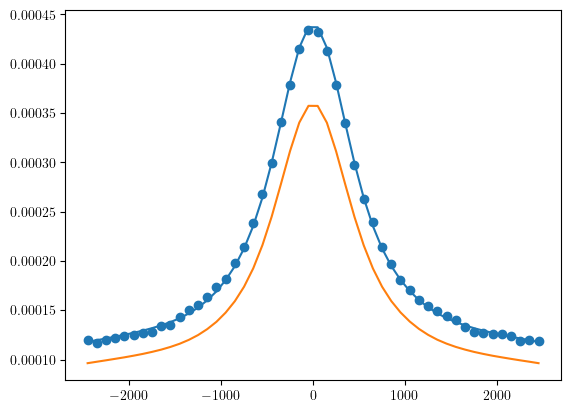

In [42]:
plt.plot(vcens, test)
plt.plot(vcens, test2)
plt.scatter(vcens, LOS_hists_MDPL2[:, 0, 0]/np.sum(LOS_hists_MDPL2[:, 0, 0]*np.diff(vcens)[0]))

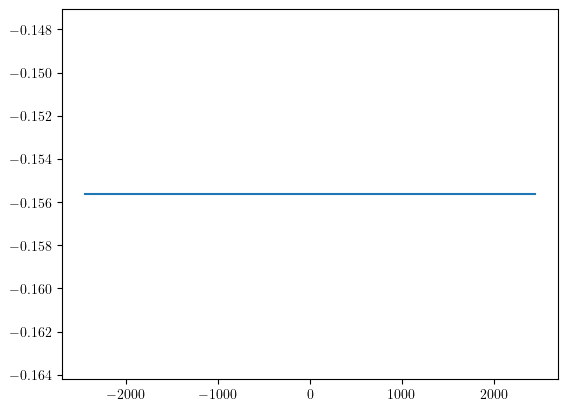

In [32]:
plt.plot(vcens, (test2-test)/test)
#plt.axhline(np.sum(test2*np.diff(vcens)[0]), ls='--', c='C1')

In [5]:
H=74.719 
a=0.83760 
h=0.6777

norms = np.zeros((len(Mvirs), len(r_cens)))

vphys = vcens

for k, M in enumerate(Mvirs):
    for i, R in tqdm(enumerate(r_cens)):
        rho_g = 0.014  # h^3 Mpc^-3 mean galaxy number density in MDPL2

        # rlos integration range
        rlos_max = 40 
        rlos_edges = np.linspace(-rlos_max, rlos_max, int(2*rlos_max + 1))
        rlos_vals = 0.5 * (rlos_edges[1:] + rlos_edges[:-1])

        Pvlos_interp_list = []

        for j in range(len(rlos_vals)):
            peak = a*H*rlos_vals[j]/h

            ve = np.linspace(-2500, 2500, 100+1)
            vc = 0.5 * (ve[1:] + ve[:-1])

            Pvlos = P_vlos_R_rlos(vc, R, rlos_vals[j], M, pars=jocond.myconfig.joint_MAP)

            interp_func = interp1d(
                vc+peak, Pvlos, kind="linear", bounds_error=False, fill_value=0.0
            )
            interpolated = interp_func(vphys[:, None])

            Pvlos_interp_list.append(interpolated)

        Pvlos_interp = np.array(Pvlos_interp_list).reshape(len(rlos_vals), len(vphys))
        Pvlos_interp = Pvlos_interp.T

        r3d = np.sqrt(R**2 + rlos_vals**2)
        weight = rho_g * (cf_inf(r3d, M, jocond.myconfig.cf_pars) + 1)

        integrand = Pvlos_interp * weight[None, :]
        P_out = simpson(integrand, x=rlos_vals, axis=1)

        norms[k, i] = np.sum(P_out * np.diff(vphys)[0])

0it [00:00, ?it/s]

10it [00:31,  3.15s/it]
10it [00:31,  3.14s/it]
10it [00:31,  3.14s/it]
10it [00:31,  3.13s/it]
10it [00:31,  3.13s/it]
10it [00:32,  3.21s/it]


In [6]:
# compute # of halos in each mass bin
halo_path = '/spiff/cosweeney/simulations/MDPL2/hlists/hlist_0.83760_update.hdf5'

N_halos = np.zeros(len(Mvirs))
with h5.File(halo_path, 'r') as hcat:
    for k in range(len(mbins)-1):
        mcut = (hcat['mvir'] > mbins[k]) & (hcat['mvir'] <= mbins[k+1])

        N_bin = mcut.sum()

        N_halos[k] = N_bin

print(N_halos)

[15071.  8200.  4095.  1691.   676.   246.]


In [7]:
vel_path = '/spiff/cosweeney/simulations/MDPL2/data/r_R_rlos_vpeclos_vphyslos_data_mass_100_cyl_6K_indmass.hdf5'

R_fine_edges = np.linspace(5, 15, 20)
R_fine_cens = 0.5*(R_fine_edges[1:]+R_fine_edges[:-1])

Sigma_RM = np.zeros((6, len(R_fine_cens)))

with h5.File(vel_path, 'r') as hdf:

    for k in range(len(Mvirs)):
        
        rs = hdf[f'R/{str(k)}'][()]

        for j in range(len(R_fine_cens)):
            
            r_mask = (rs >= R_fine_edges[j])&(rs <= R_fine_edges[j+1])

            N_pairs = r_mask.sum()

            A_shell = np.pi * ( R_fine_edges[j+1]**2 - R_fine_edges[j]**2 ) 

            Sig = N_pairs / N_halos[k] / A_shell 

            Sigma_RM[k, j] = Sig

In [8]:
Sigmas = np.array([[Sigma_inf(R, Mvirs[k], jocond.myconfig.cf_pars, max_rlos=40) for R in r_cens] for k in range(len(Mvirs))])

In [9]:
Sigmas.shape

(6, 10)

In [10]:
# compare to old method
with h5.File(vel_path, 'r') as hdf:

    isurf_dens_plot=[]
    isurf_r_plot=[]
    isurf_unc_plot=[]
    for i in range(len(mbins)-1):
        #orbit = orbit[(orbit['oi_tag'] == 3)]
        #infal = infall[(infall['hostmvir'] >= mbins[i])&(infall['hostmvir'] <= mbins[i+1])]
        gals_d = hdf[f'R/{str(k)}'][()] #infal['R']
        
        rbins = np.logspace(np.log10(5), np.log10(15), 20) 
        bin_counts, bin_edges = np.histogram(gals_d, bins=rbins)
        norm_counts = bin_counts / N_halos[i] #len(np.unique(infal['hostid']))
        bin_centres = (bin_edges[:-1] + bin_edges[1:]) / 2 #np.sqrt(bin_edges[:-1]*bin_edges[1:])# 
        bin_width = bin_centres[1] - bin_centres[0]
        bin_vol = np.pi*( bin_edges[1:]**2 - bin_edges[:-1]**2 ) #
        dens = norm_counts / bin_vol
        cf = dens/0.014 -1
        centers = bin_centres

        isurf_dens_plot.append(np.array(dens))
        isurf_r_plot.append(np.array(centers))

In [11]:
len(isurf_dens_plot)

6

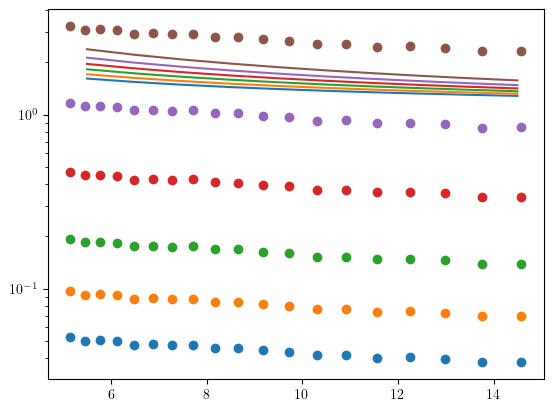

In [13]:
for k in range(len(Mvirs)):
    #plt.scatter(r_cens, norms[k])
    plt.plot(r_cens, Sigmas[k])
    #plt.scatter(R_fine_cens, Sigma_RM[k]/1.5, c=f"C{k}")
    plt.scatter(isurf_r_plot[k], isurf_dens_plot[k])

plt.yscale('log') 

In [20]:
def P_vphys_R_test(vphys, R, M, pars=jocond.myconfig.joint_MAP,
              H=74.719, a=0.83760, h=0.6777):
    
    rho_g = 0.014  # h^3 Mpc^-3

    # rlos integration range
    rlos_max = 40 
    rlos_edges = np.linspace(-rlos_max, rlos_max, int(2*rlos_max + 1))
    rlos_cens = 0.5 * (rlos_edges[1:] + rlos_edges[:-1])

    rlos_vals = rlos_cens

    Pvlos_interp_list = []

    for j in range(len(rlos_vals)):
        peak = a*H*rlos_vals[j]/h

        ve = np.linspace(-2500, 2500, 100+1)
        vc = 0.5 * (ve[1:] + ve[:-1])

        Pvlos = P_vlos_R_rlos(vc, R, rlos_vals[j], M, pars)

        interp_func = interp1d(
            vc+peak, Pvlos, kind="linear", bounds_error=False, fill_value=0.0
        )
        interpolated = interp_func(vphys[:, None])

        Pvlos_interp_list.append(interpolated)

    Pvlos_interp = np.array(Pvlos_interp_list).reshape(len(rlos_vals), len(vphys))
    Pvlos_interp = Pvlos_interp.T

    r3d = np.sqrt(R**2 + rlos_vals**2)
    weight = rho_g * (cf_inf(r3d, M, jocond.myconfig.cf_pars) + 1)
    #weight = np.array([rho_interp((M, ri)) for ri in r3d]) #

    integrand = Pvlos_interp * weight[None, :]
    P_out = simpson(integrand, x=rlos_vals, axis=1)

    sigma_R = Sigma_inf(R, M, jocond.myconfig.cf_pars)
    P_out /= sigma_R

    return P_out / simpson(P_out, x=vphys)

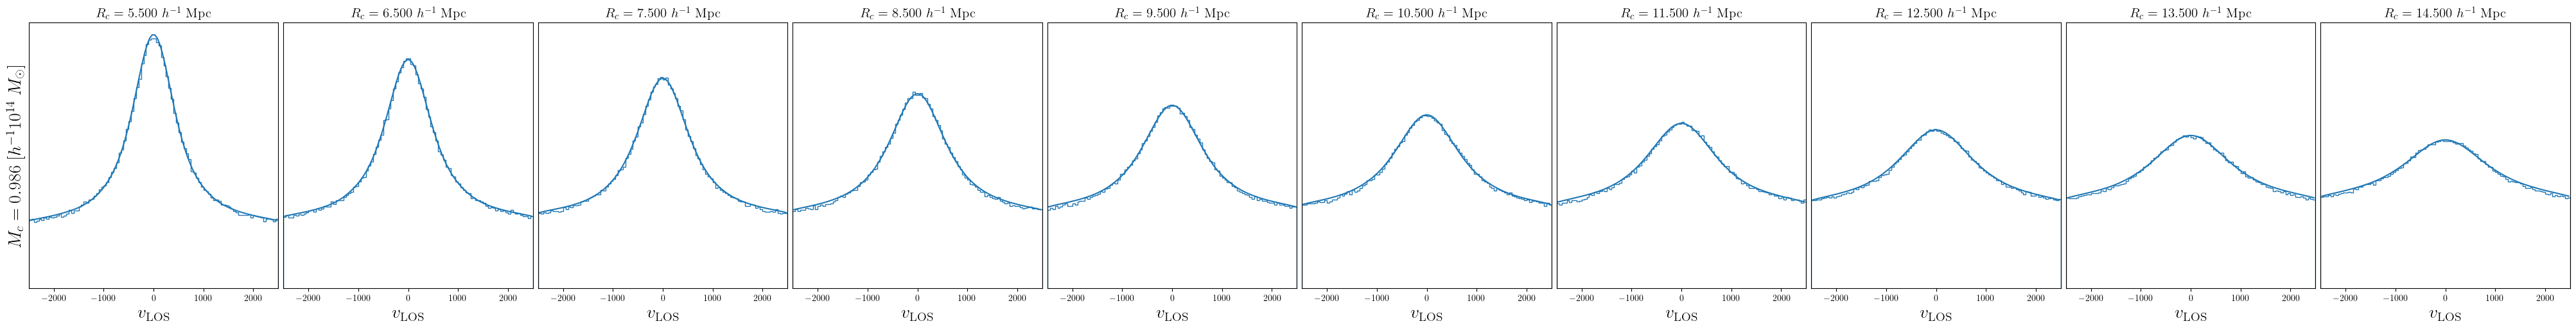

In [21]:

for k in range(len(Mvirs)-5):
    fig, ax = plt.subplots(1, len(r_cens), figsize=(40, 5), layout='constrained', sharex=True, sharey=True)
    for i in range(len(r_cens)):
        index = i + k*len(r_cens)

        hist, bins, _ = ax[i].hist(vphyslos_ls[index], bins=vedges, density=True, histtype='step', color=f'C{k}')

        ax[i].plot(vcens, P_vphys_R_test(vcens, r_cens[i], Mvirs[k]), c=f'C{k}')
        
        ax[i].set_xlabel(r"$v_{\rm LOS}$", fontsize=20)
        ax[i].set_title(rf"$R_c = {r_cens[i]:.3f} \ h^{{-1}}$ Mpc", fontsize=15)
        ax[i].set_yticks([])
        ax[i].margins(x=0)
    ax[0].set_ylabel(rf"$M_c = {(Mvirs[k]/1e14):.3f} \ [h^{{-1}} 10^{{14}} \ M_\odot]$", fontsize=20)

In [24]:
hist, v_edges = np.histogram(vphyslos_ls[0], bins='auto', range=[-2500, 2500], density=False)
print(len(hist))

146


In [29]:
import numdifftools as nd

In [34]:
# testing updates to MC for including uncertainties

par_mass_ind = np.zeros((len(mc.mvirs), len(r_cens), 2))
err_mass_ind = np.zeros((len(mc.mvirs), len(r_cens), 2))

for k in range(len(mc.mvirs)):
    p_init = [mc.mvirs[k], 0.01] #[mc.Mvirs[0]/1e14, 0.1]

    for i in range(len(r_cens)):
        soln = scipy.optimize.minimize(lambda p: -mc.RG_llh_ind(p, mc.LOS_hists[:, k, i], i), p_init, 
                                    bounds = [(0.5, 20.0), (0, 10)], #(0, np.inf), (0, np.inf), (0, np.inf)], 
                                    method='nelder-mead', 
                                    )
        
        print("Initial: ", p_init) 
        print("MLE: ", soln.x) 
        print(soln.message)

        par_mass_ind[k, i] = soln.x 

        # 2. Compute the Hessian numerically at the result point
        hessian_func = nd.Hessian(lambda p: -mc.RG_llh_ind(p, mc.LOS_hists[:, k, i], i))
        hessian_matrix = hessian_func(soln.x)

        # 3. Invert to get the Covariance Matrix
        # (Using pinv for a 'pseudo-inverse' is safer if the matrix is near-singular)
        actual_cov = np.linalg.inv(hessian_matrix)

        err_mass_ind[k, i] = np.diag(actual_cov)

Initial:  [np.float32(0.98642004), 0.01]
MLE:  [0.99830384 0.00943787]
Optimization terminated successfully.
Initial:  [np.float32(0.98642004), 0.01]
MLE:  [1.01038031e+00 4.90374565e-05]
Optimization terminated successfully.
Initial:  [np.float32(0.98642004), 0.01]
MLE:  [1.09144351 0.00122226]
Optimization terminated successfully.
Initial:  [np.float32(0.98642004), 0.01]
MLE:  [1.07499644 0.00592496]
Optimization terminated successfully.
Initial:  [np.float32(0.98642004), 0.01]
MLE:  [1.1247911  0.00475536]
Optimization terminated successfully.
Initial:  [np.float32(0.98642004), 0.01]
MLE:  [1.07884551 0.00693303]
Optimization terminated successfully.
Initial:  [np.float32(0.98642004), 0.01]
MLE:  [1.11709252 0.00792502]
Optimization terminated successfully.
Initial:  [np.float32(0.98642004), 0.01]
MLE:  [1.06498604 0.00365263]
Optimization terminated successfully.
Initial:  [np.float32(0.98642004), 0.01]
MLE:  [1.16703392 0.00541943]
Optimization terminated successfully.
Initial:  [

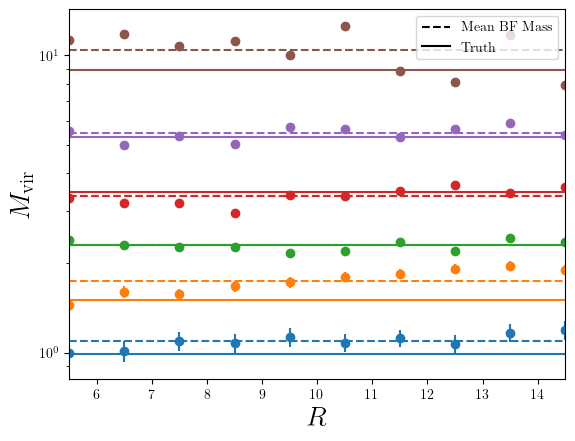

In [ ]:

fig, ax = plt.subplots()

for k in range(len(mc.mvirs)):
    #ax.scatter(mc.r_cens, par_mass_ind[k, :, 0], c=f'C{str(k)}')
    ax.errorbar(mc.r_cens, par_mass_ind[k, :, 0], np.abs(err_mass_ind[k, :, 1]), fmt='o', c=f'C{str(k)}')    
    ax.axhline(np.mean(par_mass_ind[k, :, 0]), ls='--', c=f'C{str(k)}')
    ax.axhline(mc.mvirs[k], ls='-', c=f'C{str(k)}', )


marker_1 = Line2D(
    [0], [0],
    color='k',          
    marker='none',
    linestyle='--',
    label='Mean BF Mass', 

)

marker_2 = Line2D(
    [0], [0],
    color='k',          
    marker='none',
    linestyle='-',
    label='Truth'
)

ax.set_xlabel(r'$R$', fontsize=20)
ax.set_ylabel(r'$M_{\rm vir}$', fontsize=20)
ax.set_yscale('log')
ax.margins(x=0)
#ax.set_title('Indiv. Fit to '+fit_name, fontsize=25)
plt.legend(handles=[marker_1, marker_2], fontsize=10)


In [38]:
par_mass_sim = np.zeros(7)
err_mass_sim = np.zeros(7)

p_init = np.append(mc.mvirs, 0.02)

print("Fitting bins simultaneously...")
soln = scipy.optimize.minimize(lambda p: -mc.RG_llh_sim(p, mc.LOS_hists), p_init, 
                            method='nelder-mead', 
                            options={'maxiter':10_000}
                            )

print("Initial: ",p_init) 
print("MLE: ", soln.x) 
print(soln.message)

par_mass_sim = soln.x 

mc.par_mass_sim = par_mass_sim


# 2. Compute the Hessian numerically at the result point
hessian_func = nd.Hessian(lambda p: -mc.RG_llh_sim(p, mc.LOS_hists))
hessian_matrix = hessian_func(soln.x)

# 3. Invert to get the Covariance Matrix
# (Using pinv for a 'pseudo-inverse' is safer if the matrix is near-singular)
actual_cov = np.linalg.inv(hessian_matrix)

err_mass_sim = np.diag(actual_cov)

Fitting bins simultaneously...
Initial:  [0.98642004 1.49829996 2.29630017 3.46530008 5.30749989 8.93109989
 0.02      ]
MLE:  [1.09112317e+00 1.67615224e+00 2.28782755e+00 3.33348750e+00
 5.48111652e+00 1.08310097e+01 9.76524920e-03]
Optimization terminated successfully.


(0.95, 9.8)

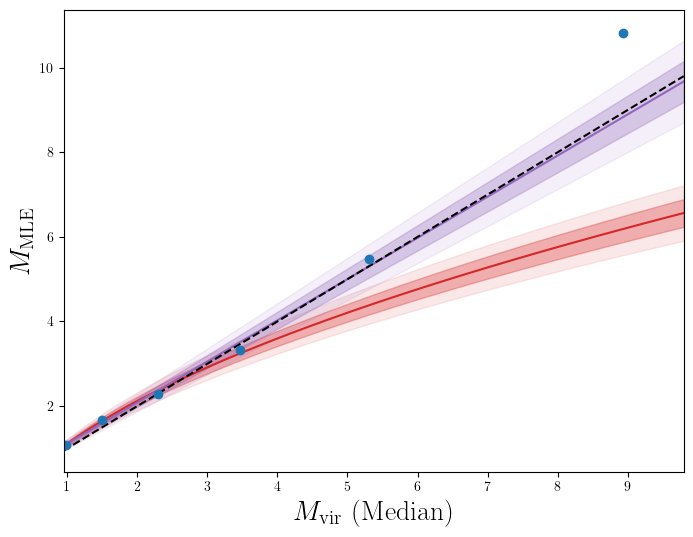

In [81]:
fig, ax = plt.subplots(figsize=(8,6))

ms = np.linspace(0.95, 9.8, 100)

def plawc(x, a, b, c):
    return a*x**b + c

p_plc, c = curve_fit(plawc, mc.mvirs, par_mass_sim[:-1], sigma=err_mass_sim[:-1], absolute_sigma=True)
ax.plot(ms, plawc(ms, p_plc[0], p_plc[1], p_plc[2]), c='C3', ls='-', )
ax.fill_between(ms, (1-0.05)*plawc(ms, p_plc[0], p_plc[1], p_plc[2]), (1+0.05)*plawc(ms, p_plc[0], p_plc[1], p_plc[2]), color='C3', alpha=0.3)
ax.fill_between(ms, (1-0.1)*plawc(ms, p_plc[0], p_plc[1], p_plc[2]), (1+0.1)*plawc(ms, p_plc[0], p_plc[1], p_plc[2]), color='C3', alpha=0.1)


p, c = curve_fit(line, mc.mvirs, par_mass_sim[:-1], sigma=err_mass_sim[:-1], absolute_sigma=True)
ax.plot(ms, line(ms, p[0], p[1]), c='C4', ls='-', )
ax.fill_between(ms, (1-0.05)*line(ms, p[0], p[1]), (1+0.05)*line(ms, p[0], p[1]), color='C4', alpha=0.3)
ax.fill_between(ms, (1-0.1)*line(ms, p[0], p[1]), (1+0.1)*line(ms, p[0], p[1]), color='C4', alpha=0.1)


#M_est_pars[i] = p
#ax.scatter(mvirs, np.mean(par_mass_ind[i, :, :, 0], axis=-1), label='Mean of Ind. bins')
#ax.scatter(mvirs, par_mass[:, 0], marker='s', label=r'All R $|$ M')
ax.errorbar(mc.mvirs, par_mass_sim[:-1], err_mass_sim[:-1], fmt='o',  label='All R+M bins simult.')
ax.plot(ms, line(ms, 1, 0), c='k', ls='--', label=r'$M_{\rm MLE} = M_{\rm vir}$')
ax.margins(x=0)
ax.set_ylabel(r'$M_{\rm MLE}$', fontsize=20)
ax.set_xlabel(r'$M_{\rm vir}$ (Median)', fontsize=20)
#ax.legend(fontsize=14)
#ax.set_yscale('log')
#ax.set_xscale('log')
ax.set_xlim((0.95, 9.8))
#ax.set_title(titles[i], fontsize=25)

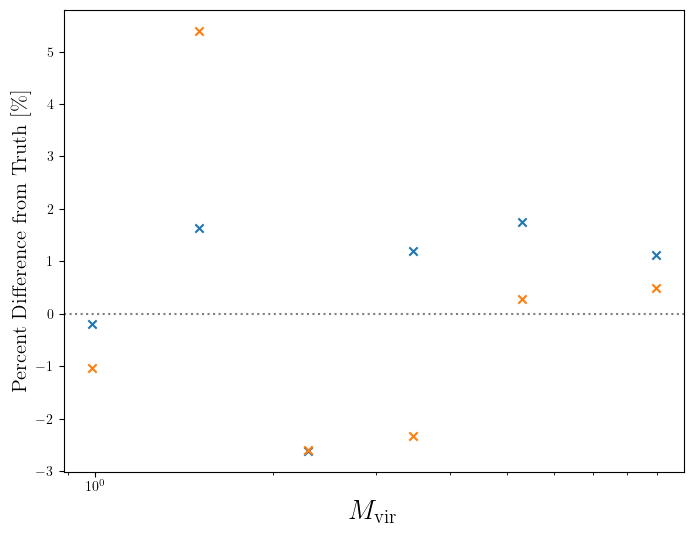

In [67]:
fig, ax = plt.subplots(figsize=(8,6))


#ax.scatter(mc.mvirs, ((par_mass_ind[j, :, 0]-mc.mvirs)/mc.mvirs)*100, marker='x')
#ax.axhline(np.mean(np.abs((par_mass_ind[j, :, 0]-mc.mvirs)/mc.mvirs))*100, label=r'All $R | M$', c='C1') 
mpc = plawc(mc.mvirs, p_plc[0], p_plc[1], p_plc[2])
ml = line(mc.mvirs, p[0], p[1])

ax.scatter(mc.mvirs, ((par_mass_sim[:-1]-mpc)/err_mass_sim[:-1])/100, marker='x')
ax.scatter(mc.mvirs, ((par_mass_sim[:-1]-ml)/err_mass_sim[:-1])/100, marker='x')

#print(((par_mass_sim[:-1]-mpc)/mpc)*100)
#print(((par_mass_sim[:-1]-ml)/ml)*100)
# ax.axhline(np.mean(np.abs((par_mass_sim[:-1]-mpc)/mpc))*100, label=r'All $R+M$ simult. avg PD', c='C0') 
# ax.axhline(np.mean(np.abs((par_mass_sim[:-1]-ml)/ml))*100, label=r'All $R+M$ simult. avg PD', c='C1') 

#ax.axhline(-np.mean(np.abs((par_mass_sim[:-1]-mc.mvirs)/mc.mvirs))*100, c='C1') 

ax.axhline(0.0, c='k', ls=':', alpha=0.5)
ax.set_xlabel(r"$M_{\rm vir}$", fontsize=20) 
ax.set_ylabel(r"Percent Difference from Truth $[\%]$", fontsize=15) 
ax.set_xscale('log')

